In [3]:
from qutip import *
import numpy as np
import matplotlib.pyplot as plt

# Single mode squeezing

Need damping to prevent parametric instability from exciting us far outside of the Hilbert space:

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Wigner function'}, xlabel='$\\rm{Re}(\\alpha)$', ylabel='$\\rm{Im}(\\alpha)$'>)

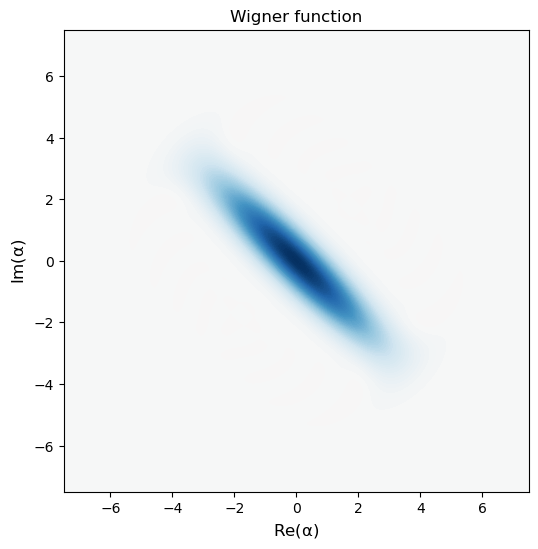

In [45]:
N = 20
a = destroy(N)
kappa = 1
eps = 0.23

H = eps*(a*a + a.dag()*a.dag())
c_ops = [np.sqrt(kappa)*a]

res = steadystate(H, c_ops)
plot_wigner(res)

# Single mode parametron

Damped:

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Wigner function'}, xlabel='$\\rm{Re}(\\alpha)$', ylabel='$\\rm{Im}(\\alpha)$'>)

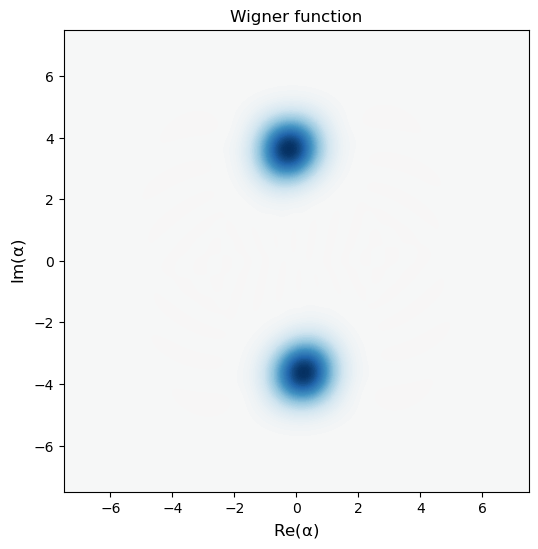

In [102]:
N = 20
a = destroy(N)
kappa = 1
eps = 2
K = 0.3

H = eps*(a*a + a.dag()*a.dag()) + K*(a.dag()*a.dag()*a*a)
c_ops = [np.sqrt(kappa)*a]

res = steadystate(H, c_ops)
plot_wigner(res)

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Wigner function'}, xlabel='$\\rm{Re}(\\alpha)$', ylabel='$\\rm{Im}(\\alpha)$'>)

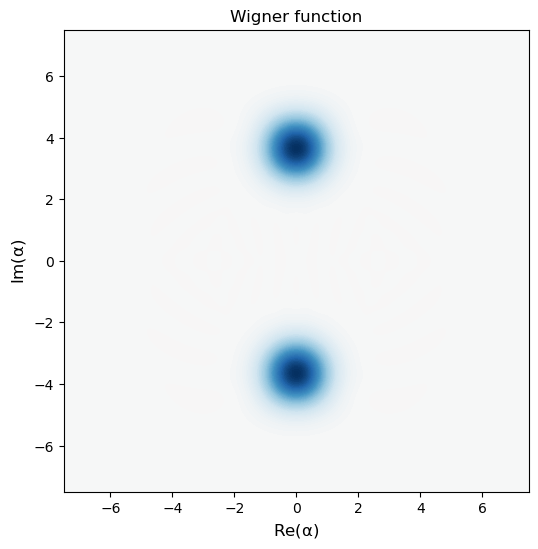

In [55]:
N = 20
a = destroy(N)
kappa = 0.000001 # for steady state, kappa cannot be zero
eps = 2
K = 0.3

H = eps*(a*a + a.dag()*a.dag()) + K*(a.dag()*a.dag()*a*a)
c_ops = [np.sqrt(kappa)*a]

res = steadystate(H, c_ops)
plot_wigner(res)

# Two mode squeezing

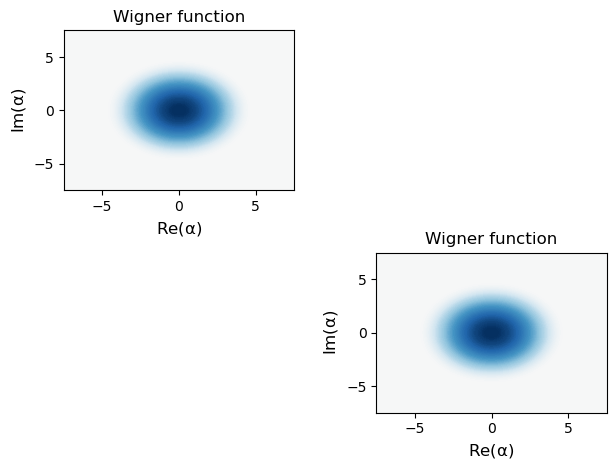

In [89]:
N = 10
a = tensor(destroy(N), identity(N))
b = tensor(identity(N), destroy(N))

kappa = 1
eps = 0.5

H = eps*(a*b + a.dag()*b.dag())
c_ops = [np.sqrt(kappa)*a, np.sqrt(kappa)*b]

res = steadystate(H, c_ops)
ax = plt.subplot(2,2,1)
plot_wigner(res.ptrace(0), ax=ax)
ax = plt.subplot(2,2,4)
plot_wigner(res.ptrace(1), ax=ax)
plt.tight_layout()

Seems there is no easy way to calculate cross wigner functions...:

https://groups.google.com/g/qutip/c/A5Cjq3PZcU8?pli=1

The other two quadrants of my plots will have to wait...

# Two Mode squeezing with one Kerr oscillator

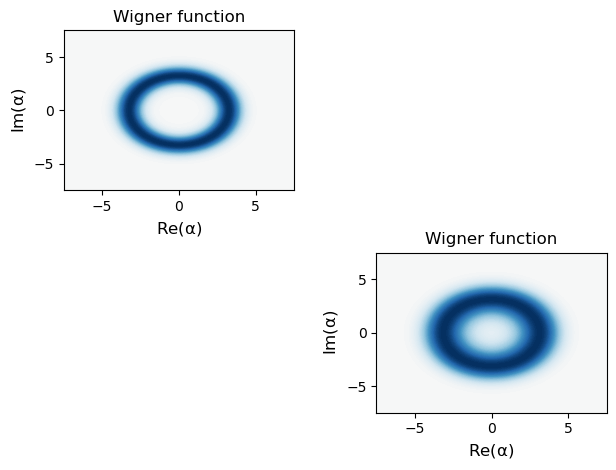

In [111]:
N = 20
a = tensor(destroy(N), identity(N))
b = tensor(identity(N), destroy(N))

kappa = .0001
eps = 1.5
K = 0.3

H = eps*(a*b + a.dag()*b.dag()) + K*a.dag()*a.dag()*a*a
c_ops = [np.sqrt(kappa)*a, np.sqrt(kappa)*b]

res = steadystate(H, c_ops)
ax = plt.subplot(2,2,1)
plot_wigner(res.ptrace(0), ax=ax)
ax = plt.subplot(2,2,4)
plot_wigner(res.ptrace(1), ax=ax)
plt.tight_layout()

First thing to note is that we now have a fininte steady state also in the absense of damping, suggesting parametron-like physics. My strong suspicion is that if we were able to calculate the "cross" Wigner functions, we would see well-defined parametron states. 